In [1]:
import pandas as ps
import yfinance as yf
import datetime as dt

In [2]:
start=dt.datetime(2020,1,1)
end=dt.datetime(2023,12,31)
stk_data=yf.download("RELIANCE.NS",start="2020-1-1",end="2023-12-31")

[*********************100%***********************]  1 of 1 completed


In [3]:
stk_data.columns=stk_data.columns.get_level_values(0)
stk_data.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')

In [4]:
stk_data=stk_data[["Open","High","Low","Close"]]
stk_data

Price,Open,High,Low,Close
Date,,,,
2020-01-01,675.956671,680.008852,670.390532,672.216187
2020-01-02,673.284921,686.176208,673.284921,683.660278
2020-01-03,682.636062,686.487896,678.183128,684.484070
2020-01-06,676.847260,680.365044,667.050769,668.609314
2020-01-07,676.401995,683.304098,673.952887,678.895691
...,...,...,...,...
2023-12-22,1264.550536,1275.073539,1258.646635,1267.243042
2023-12-26,1268.700501,1280.532788,1266.082053,1273.665649
2023-12-27,1275.617031,1284.460338,1271.220103,1278.013184


In [5]:
stk_data.to_csv("RELIANCE.NS.csv")

In [6]:
column="Close"

In [7]:
from sklearn.preprocessing import MinMaxScaler
ms=MinMaxScaler()
data1=ms.fit_transform(stk_data[[column]])
print("Len:",data1.shape)

Len: (992, 1)


In [8]:
orders=[(0,0,0),(0,0,1),(2,0,1),(1,1,1)]
for i in orders:
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    model = SARIMAX(data1, order=i, seasonal_order=(0,0,0,12))
    model_fit = model.fit()
   
    y_pred= model_fit.predict(0, len(data1)-1)
    
    from stockFunctions import rmsemape
    rmsemape(data1,y_pred)

RMSE-Testset: 0.7247170111915173
MAPE-Testset: 0.998991935483871
RMSE-Testset: 0.3692237782090861
MAPE-Testset: 181623641356.86798


C:\Anaconda3\envs\aitsa\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Anaconda3\envs\aitsa\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


RMSE-Testset: 0.021283744440589603
MAPE-Testset: 302705003131.9519
RMSE-Testset: 0.02127817376652264
MAPE-Testset: 303126645984.16876


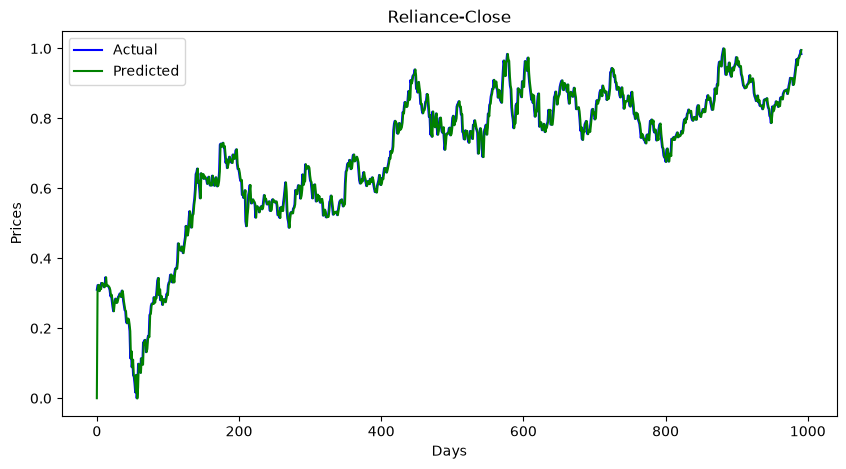

In [9]:
from stockFunctions import graph
graph(data1,y_pred,"Actual","Predicted","Reliance-Close","Days","Prices")

In [10]:
len(data1)

992

In [11]:
from stockFunctions import conversionSingle
aTestNormTable=conversionSingle(data1,["Close"])
actual_stock_price_test_ori=ms.inverse_transform(aTestNormTable)
actual_stock_price_test_oriA=conversionSingle(actual_stock_price_test_ori,["Close"])

In [12]:
from stockFunctions import conversionSingle
pTestNormTable=conversionSingle(y_pred,["Close"])
predicted_stock_price_test_ori=ms.inverse_transform(pTestNormTable)
predicted_stock_price_test_oriP=conversionSingle(predicted_stock_price_test_ori,["Close"])

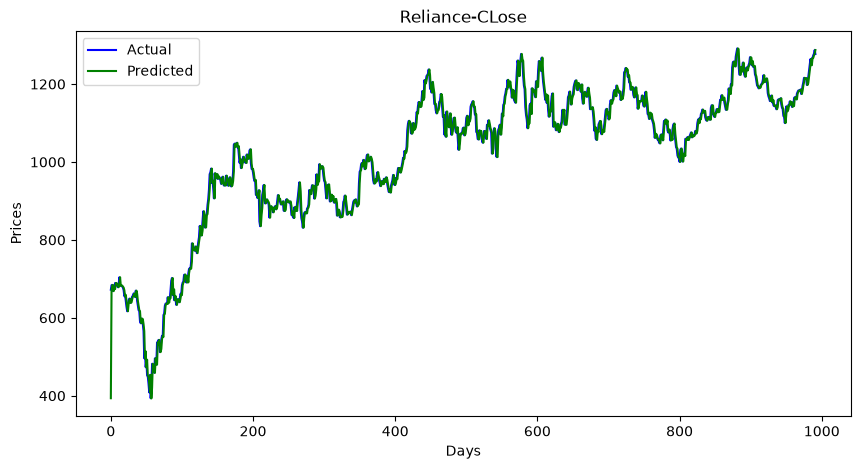

In [13]:
from stockFunctions import graph
graph(actual_stock_price_test_oriA,predicted_stock_price_test_oriP,"Actual","Predicted","Reliance-CLose","Days","Prices")

In [14]:
from stockFunctions import rmsemape
rmsemape(actual_stock_price_test_oriA,predicted_stock_price_test_oriP)

RMSE-Testset: 19.100607749471184
MAPE-Testset: 0.013453880189433476


In [15]:
forecast=model_fit.predict(len(data1), len(data1)+1)

In [16]:
forecast

array([0.9840073 , 0.98406918])

In [17]:
from stockFunctions import conversionSingle
fTestNormTable=conversionSingle(forecast,["Closefore"])
forecast_stock_price_test_ori=ms.inverse_transform(fTestNormTable)
forecast_stock_price_test_oriF=conversionSingle(forecast_stock_price_test_ori,["Closefore"])

In [18]:
forecast_stock_price_test_oriF.to_csv("Closets.csv",index=False)

In [19]:
forecast_stock_price_test_oriF

,Closefore
0,1276.968301
1,1277.023853


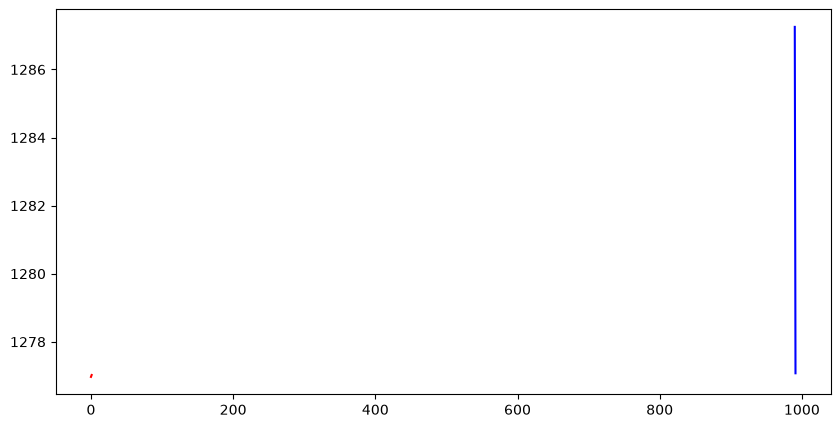

In [20]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(actual_stock_price_test_oriA[-2:], color = 'blue', label="Actual")
plt.plot(forecast_stock_price_test_oriF, color = 'red', label ="Predicted")